In [157]:
import time
import pandas as pd
import numpy as np
import pymysql


import ta
from sklearn.model_selection import train_test_split

import datetime

In [158]:
import pandas as pd

# 定义存储DataFrame的列表
dataframes = []

for year in range(2019, 2024):
    filename = f"{year}.csv"
    
    df = pd.read_csv(filename)
    
    dataframes.append(df)



In [159]:
import pandas as pd

# 定义存储DataFrame的列表
dataframes = []

# 遍历年份2019到2023
for year in range(2019, 2024):
    # 构建文件名
    filename = f"{year}.csv"
    
    # 读取CSV文件
    df = pd.read_csv(filename)
    
    # 将DataFrame添加到列表中
    dataframes.append(df)

# 使用pd.concat合并所有DataFrame对象
combined_df = pd.concat(dataframes, ignore_index=True)

# 此时，combined_df是一个包含了2019到2023年所有数据的DataFrame


In [160]:
combined_df

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,09/08/2019,20:00,Liverpool,Norwich,4,1,H,4,0,...,3.43,-2.25,1.91,1.99,1.94,1.98,1.99,2.07,1.90,1.99
1,E0,10/08/2019,12:30,West Ham,Man City,0,5,A,0,1,...,2.91,1.75,1.95,1.95,1.96,1.97,2.07,1.98,1.97,1.92
2,E0,10/08/2019,15:00,Bournemouth,Sheffield United,1,1,D,0,0,...,1.92,-0.50,1.95,1.95,1.98,1.95,2.00,1.96,1.96,1.92
3,E0,10/08/2019,15:00,Burnley,Southampton,3,0,H,0,0,...,1.71,0.00,1.87,2.03,1.89,2.03,1.90,2.07,1.86,2.02
4,E0,10/08/2019,15:00,Crystal Palace,Everton,0,0,D,0,0,...,1.71,0.25,1.82,2.08,1.97,1.96,2.03,2.08,1.96,1.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1743,E0,04/02/2024,14:00,Bournemouth,Nott'm Forest,1,1,D,1,1,...,2.40,-0.75,1.83,2.10,1.84,2.10,1.85,2.12,1.81,2.07
1744,E0,04/02/2024,14:00,Chelsea,Wolves,2,4,A,1,2,...,2.37,-1.00,1.88,2.05,1.88,2.04,1.95,2.06,1.87,2.00
1745,E0,04/02/2024,14:00,Man United,West Ham,3,0,H,1,0,...,2.40,-1.00,1.90,2.03,1.93,2.00,2.02,2.06,1.89,1.99
1746,E0,04/02/2024,16:30,Arsenal,Liverpool,3,1,H,1,1,...,2.20,-0.25,1.92,2.01,1.93,2.00,2.00,2.01,1.91,1.95


In [161]:
import pandas as pd

epl_1718 = combined_df[['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG']]

print(epl_1718.head())


         HomeTeam          AwayTeam  FTHG  FTAG
0       Liverpool           Norwich     4     1
1        West Ham          Man City     0     5
2     Bournemouth  Sheffield United     1     1
3         Burnley       Southampton     3     0
4  Crystal Palace           Everton     0     0


In [162]:
combined_df.to_csv('football_combined.csv')

In [163]:
combined_df[["FTHG", "FTAG"]].mean()


FTHG    1.540046
FTAG    1.287757
dtype: float64

Text(0.5, 1.0, 'Number of Goals Scored Per Match')

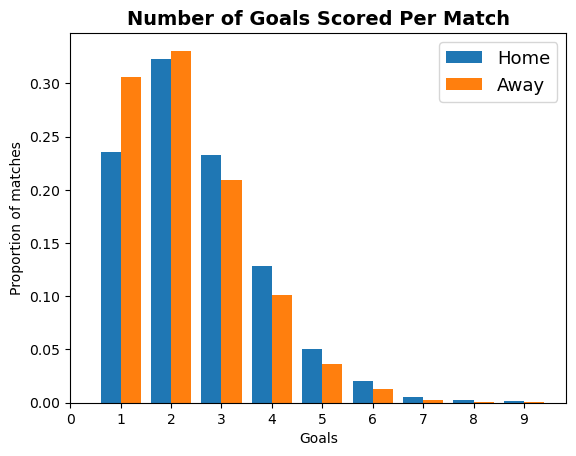

In [164]:
max_goals = 10
plt.hist(
    combined_df[["FTHG", "FTAG"]].values, range(max_goals), label=["Home", "Away"], density=True
)
plt.xticks([i - 0.5 for i in range(max_goals)], [i for i in range(max_goals)])
plt.xlabel("Goals")
plt.ylabel("Proportion of matches")
plt.legend(loc="upper right", fontsize=13)
plt.title("Number of Goals Scored Per Match", size=14, fontweight="bold")

Text(0.5, 1.0, 'Number of Goals Scored Per Match')

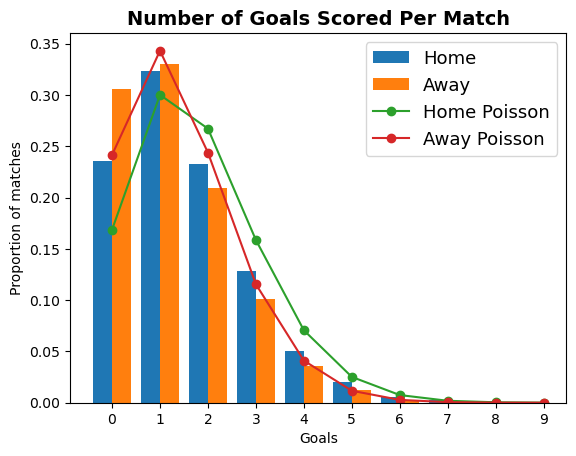

In [165]:
import numpy as np
from scipy.stats import poisson

home_poisson = poisson.pmf(range(10), df["FTHG"].mean())
away_poisson = poisson.pmf(range(10), df["FTAG"].mean())

max_goals = 10
plt.hist(
    combined_df[["FTHG", "FTAG"]].values, range(max_goals), label=["Home", "Away"], density=True
)

plt.plot(
    [i - 0.5 for i in range(1, max_goals + 1)],
    home_poisson,
    linestyle="-",
    marker="o",
    label="Home Poisson",
)

plt.plot(
    [i - 0.5 for i in range(1, max_goals + 1)],
    away_poisson,
    linestyle="-",
    marker="o",
    label="Away Poisson",
)


plt.xticks([i - 0.5 for i in range(1, max_goals + 1)], [i for i in range(max_goals)])
plt.xlabel("Goals")
plt.ylabel("Proportion of matches")
plt.legend(loc="upper right", fontsize=13)
plt.title("Number of Goals Scored Per Match", size=14, fontweight="bold")


ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of labels (9).

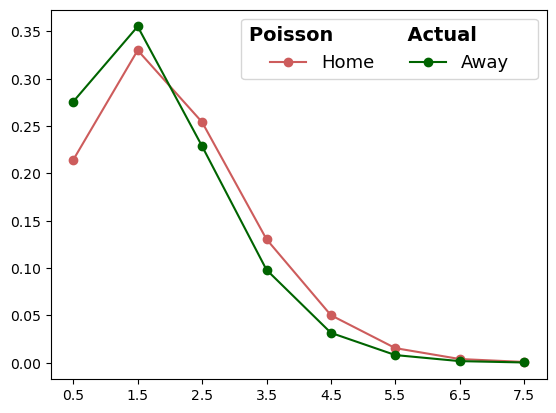

In [166]:


# add lines for the Poisson distributions
pois1, = plt.plot([i-0.5 for i in range(1,9)], poisson_pred[:,0],
                  linestyle='-', marker='o',label="Home", color = '#CD5C5C')
pois2, = plt.plot([i-0.5 for i in range(1,9)], poisson_pred[:,1],
                  linestyle='-', marker='o',label="Away", color = '#006400')

leg=plt.legend(loc='upper right', fontsize=13, ncol=2)
leg.set_title("Poisson           Actual        ", prop = {'size':'14', 'weight':'bold'})

plt.xticks([i-0.5 for i in range(1,9)],[i for i in range(9)])
plt.xlabel("Goals per Match",size=13)
plt.ylabel("Proportion of Matches",size=13)
plt.title("Number of Goals per Match (EPL 2017/18 Season)",size=14,fontweight='bold')
plt.ylim([-0.004, 0.4])
plt.tight_layout()
plt.show()

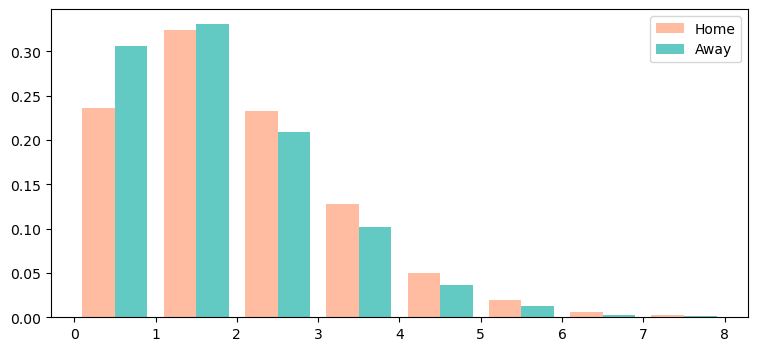

In [167]:
import matplotlib.pyplot as plt

# 假设 epl_1718 是你的 DataFrame，包含了列 'FTHG' 和 'FTAG'
fig, ax = plt.subplots(figsize=(9, 4))  

# 修正后的代码使用 density=True 替代了 normed=True
# 并且建议使用 .to_numpy() 方法，虽然在这个场景下直接使用 .values 也是可以工作的
plt.hist(epl_1718[['FTHG', 'FTAG']].to_numpy(), range(9), 
         alpha=0.7, label=['Home', 'Away'], density=True, color=["#FFA07A", "#20B2AA"])

# 接下来的代码可能需要根据你的具体需求进行调整
# 这里只修正了你遇到错误的部分
plt.legend()
plt.show()


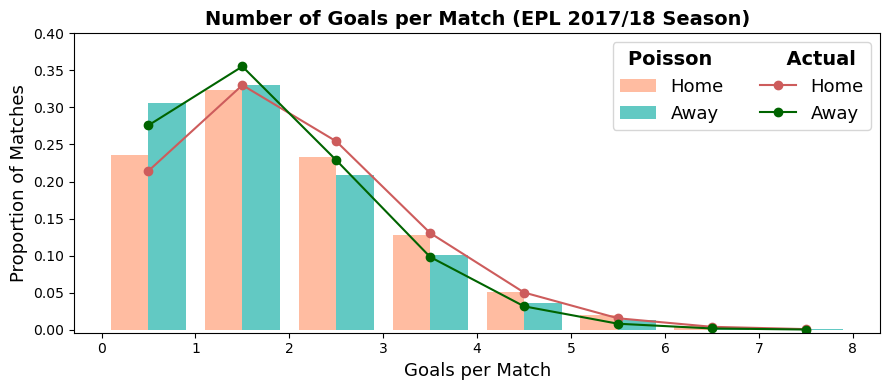

In [168]:
import matplotlib.pyplot as plt
import numpy as np

# 假设 epl_1718 是你的 DataFrame，包含了列 'FTHG' 和 'FTAG'
# 假设 poisson_pred 是一个 Numpy 数组，包含了泊松预测的结果
# poisson_pred[:,0] 对应主队的进球预测，poisson_pred[:,1] 对应客队的进球预测

fig, ax = plt.subplots(figsize=(9, 4))  

# 绘制实际进球的直方图
plt.hist(epl_1718[['FTHG', 'FTAG']].to_numpy(), range(9), 
         alpha=0.7, label=['Home', 'Away'], density=True, color=["#FFA07A", "#20B2AA"])

# 绘制泊松预测的曲线
pois1, = plt.plot([i-0.5 for i in range(1,9)], poisson_pred[:,0],
                  linestyle='-', marker='o', label="Home", color = '#CD5C5C')
pois2, = plt.plot([i-0.5 for i in range(1,9)], poisson_pred[:,1],
                  linestyle='-', marker='o', label="Away", color = '#006400')

# 设置图例
leg = plt.legend(loc='upper right', fontsize=13, ncol=2)
leg.set_title("Poisson           Actual", prop={'size':'14', 'weight':'bold'})

# 设置x轴和y轴标签，图表标题，以及y轴的范围
plt.xticks([i for i in range(9)], [i for i in range(9)])
plt.xlabel("Goals per Match", size=13)
plt.ylabel("Proportion of Matches", size=13)
plt.title("Number of Goals per Match (EPL 2017/18 Season)", size=14, fontweight='bold')
plt.ylim([-0.004, 0.4])

plt.tight_layout()
plt.show()


In [100]:
epl_1718

,HomeTeam,AwayTeam,FTHG,FTAG
0,Liverpool,Norwich,4,1
1,West Ham,Man City,0,5
2,Bournemouth,Sheffield United,1,1
3,Burnley,Southampton,3,0
4,Crystal Palace,Everton,0,0
...,...,...,...,...
1743,Bournemouth,Nott'm Forest,1,1
1744,Chelsea,Wolves,2,4
1745,Man United,West Ham,3,0
1746,Arsenal,Liverpool,3,1


In [99]:
# importing the tools required for the Poisson regression model
import statsmodels.api as sm
import statsmodels.formula.api as smf

goal_model_data = pd.concat([epl_1718[['HomeTeam','AwayTeam','FTHG']].assign(home=1).rename(
            columns={'HomeTeam':'team', 'AwayTeam':'opponent','FTHG':'goals'}),
           epl_1718[['AwayTeam','HomeTeam','FTAG']].assign(home=0).rename(
            columns={'AwayTeam':'team', 'HomeTeam':'opponent','FTAG':'goals'})])

poisson_model = smf.glm(formula="goals ~ home + team + opponent", data=goal_model_data, 
                        family=sm.families.Poisson()).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                 3496
Model:                            GLM   Df Residuals:                     3444
Model Family:                 Poisson   Df Model:                           51
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -5132.0
Date:                Sat, 17 Feb 2024   Deviance:                       3976.0
Time:                        10:05:56   Pearson chi2:                 3.50e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1579
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [131]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 假设df是你的DataFrame，包含了列'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG'

# 创建进球数的泊松回归模型，模型中需要考虑主队和客队
# 这里仅为示例，实际的模型构建可能更复杂
model = smf.glm(formula="FTHG ~ HomeTeam + AwayTeam", data=df, family=sm.families.Poisson()).fit()
print(model.summary())

# 输出的系数可以用来解释每个队伍的攻击和防守能力


                 Generalized Linear Model Regression Results                  
Dep. Variable:                   FTHG   No. Observations:                  228
Model:                            GLM   Df Residuals:                      189
Model Family:                 Poisson   Df Model:                           38
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -346.52
Date:                Sat, 17 Feb 2024   Deviance:                       213.61
Time:                        11:54:14   Pearson chi2:                     180.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2344
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [148]:
poisson_model.predict(pd.DataFrame(data={'team': 'Man City', 'opponent': 'Liverpool',
                                       'home':1},index=[1]))

1    1.872665
dtype: float64

In [149]:
poisson_model.predict(pd.DataFrame(data={'team': 'Liverpool', 'opponent': 'Man City',
                                       'home':0},index=[1]))

1    1.228466
dtype: float64

In [150]:
def simulate_match(foot_model, homeTeam, awayTeam, max_goals=10):
    home_goals_avg = foot_model.predict(pd.DataFrame(data={'team': homeTeam, 
                                                            'opponent': awayTeam,'home':1},
                                                      index=[1])).values[0]
    away_goals_avg = foot_model.predict(pd.DataFrame(data={'team': awayTeam, 
                                                            'opponent': homeTeam,'home':0},
                                                      index=[1])).values[0]
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in [home_goals_avg, away_goals_avg]]
    return(np.outer(np.array(team_pred[0]), np.array(team_pred[1])))
ars_sou = simulate_match(poisson_model, 'Man City', 'Liverpool', max_goals=10)
print(ars_sou[0:5, 0:5])

[[0.04499829 0.05527888 0.03395412 0.01390383 0.0042701 ]
 [0.08426669 0.1035188  0.06358468 0.02603721 0.00799646]
 [0.07890163 0.09692799 0.05953639 0.02437948 0.00748734]
 [0.04925209 0.06050454 0.03716389 0.0152182  0.00467376]
 [0.02305816 0.02832618 0.01739888 0.00712464 0.0021881 ]]


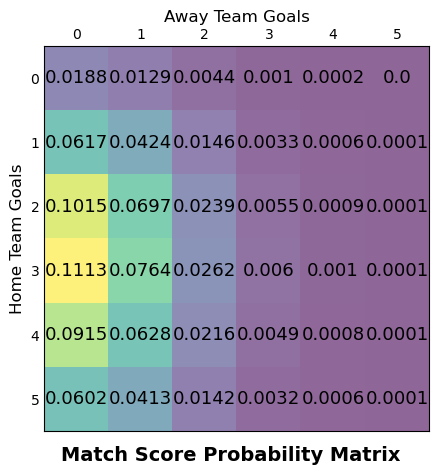

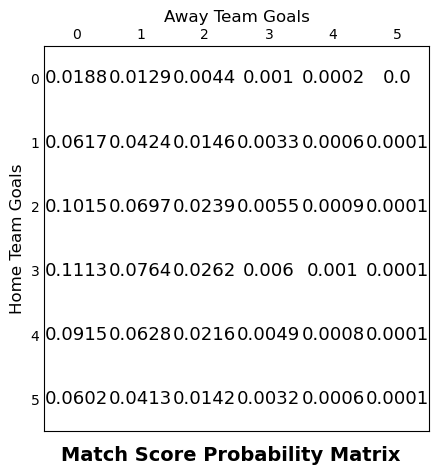

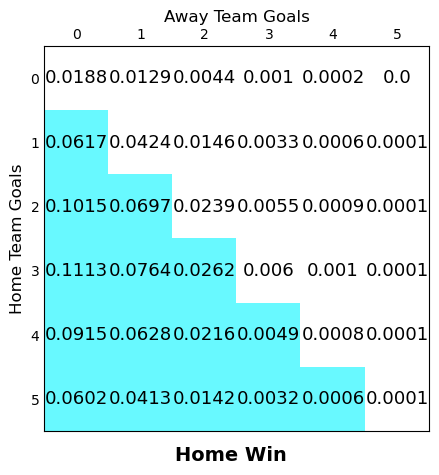

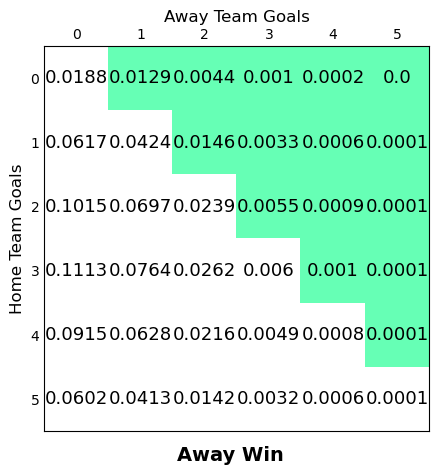

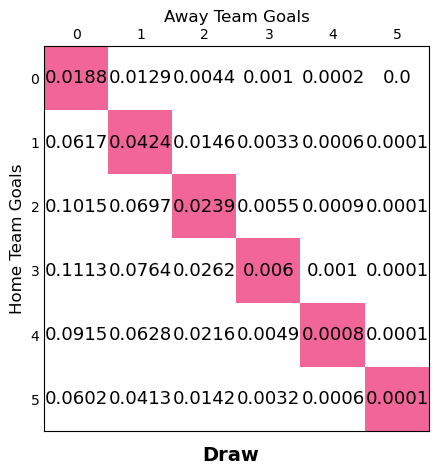

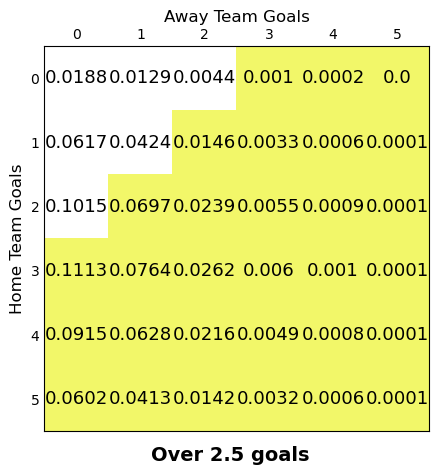

In [135]:
from matplotlib.colors import ListedColormap

def matrix_gif(matrix, colour_matrix, colour_map, subtitle="", heatmap=False, alpha=0.8):
    fig, ax1 = plt.subplots(1, figsize=(5,5))
    if heatmap:
        ax1.matshow(matrix, alpha=alpha)
    else:
        ax1.matshow(colour_matrix, cmap=colour_map, alpha=alpha)
    ax1.tick_params(axis=u'both', which=u'both',length=0)
    ax1.grid(which='major', axis='both', linestyle='')
    ax1.set_xlabel('Away Team Goals', fontsize=12)
    ax1.set_ylabel('Home Team Goals', fontsize=12)
    ax1.xaxis.set_label_position('top')
    nrows, ncols = matrix.shape
    for i in range(nrows):
        for j in range(ncols):
            c = matrix[i][j]
            ax1.text(j, i, str(round(c,4)), va='center', ha='center', size=13)
    plt.figtext(0.5, 0.05, subtitle, horizontalalignment='center',
                fontsize=14, multialignment='left', fontweight='bold')
    return fig

cmap = ListedColormap(['w', '#04f5ff', '#00ff85', '#e90052'])
matrix = simulate_match(poisson_model, 'Man City', 'Liverpool', max_goals=5)
matn = len(matrix)
matrix_gif(matrix, matrix, ListedColormap(['w']), heatmap=True, 
           alpha=0.6, subtitle="Match Score Probability Matrix").savefig("match_matrix_0.png")

for t,(mat,colour,subtitle) in enumerate(zip([np.zeros((matn, matn)), np.tril(np.ones((matn,matn)),-1),
                            np.triu(np.ones((matn,matn))*2,1), np.diag([3]*matn),
                                             np.array([0 if i+j<3 else 1 for i in range(matn) for j in range(matn)]).reshape(matn,matn)],
                          ['w', '#04f5ff', '#00ff85', '#e90052','#EAF205'],
                                   ['Match Score Probability Matrix', 'Home Win', 'Away Win', 'Draw', 'Over 2.5 goals'])):
    matrix_gif(matrix, mat, ListedColormap(['w'] + [colour]), heatmap=False, 
               alpha=0.6, subtitle=subtitle).savefig("match_matrix_{}.png".format(t+1))


In [136]:
def poiss_actual_diff(football_url, max_goals):
    epl_1718 = pd.read_csv(football_url)
    epl_1718 = epl_1718[['HomeTeam','AwayTeam','FTHG','FTAG']]
    epl_1718 = epl_1718.rename(columns={'FTHG': 'HomeGoals', 'FTAG': 'AwayGoals'})
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals)] \
                 for team_avg in [epl_1718['HomeGoals'].mean(), epl_1718['AwayGoals'].mean()]]
    return np.outer(np.array(team_pred[0]), np.array(team_pred[1])) - \
        np.array([sum((epl_1718['HomeGoals']==i) & (epl_1718['AwayGoals']==j)) 
                  for i in range(max_goals) for j in range(max_goals)]).reshape((6,6))/len(epl_1718)

year_arrays = []
for year in range(2005,2018):
    year_arrays.append(poiss_actual_diff("http://www.football-data.co.uk/mmz4281/{}{}/E0.csv".format(
        str(year)[-2:], str(year+1)[-2:]),6))

ParserError: Error tokenizing data. C error: Expected 1 fields in line 7, saw 6


In [137]:
import pandas as pd
import numpy as np
from scipy.stats import poisson

def poiss_actual_diff(file_path, max_goals):
    epl_data = pd.read_csv(file_path)
    epl_data = epl_data[['HomeTeam','AwayTeam','FTHG','FTAG']]
    epl_data = epl_data.rename(columns={'FTHG': 'HomeGoals', 'FTAG': 'AwayGoals'})
    
    # 计算主队和客队进球的平均值的泊松分布
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals)] \
                 for team_avg in [epl_data['HomeGoals'].mean(), epl_data['AwayGoals'].mean()]]
    
    # 计算实际与预测的差异
    matrix_diff = np.outer(np.array(team_pred[0]), np.array(team_pred[1])) - \
        np.array([sum((epl_data['HomeGoals']==i) & (epl_data['AwayGoals']==j)) 
                  for i in range(max_goals) for j in range(max_goals)]).reshape((max_goals,max_goals))/len(epl_data)
    
    return matrix_diff

year_arrays = []
for year in range(2005, 2024):  # 包括2005年到2023年
    file_name = "{}.csv".format(year)  # 构造文件名
    year_arrays.append(poiss_actual_diff(file_name, 6))


In [138]:
year_arrays

[array([[-8.19162497e-04,  1.16822119e-02, -1.68321864e-02,
         -3.51138919e-03, -4.07904008e-03,  7.81213706e-04],
        [-2.03099818e-02,  4.04693801e-02, -4.60462683e-03,
         -7.17141260e-03, -2.32181131e-03,  1.14098318e-03],
        [-1.63205511e-02,  1.21017738e-02,  1.76554162e-02,
         -2.51887437e-03, -1.19345569e-03, -1.79836097e-03],
        [ 3.82732173e-03,  2.22129292e-03, -9.96012745e-04,
          2.47869205e-03,  1.98130239e-03,  4.05645594e-04],
        [-2.61048796e-03, -7.49918512e-03,  3.89440637e-04,
         -5.06794295e-03,  7.23436069e-04,  1.48114016e-04],
        [-6.44808742e-04, -5.35426788e-04,  2.41985184e-03,
          8.25721374e-04,  2.11319483e-04,  4.32648837e-05]]),
 array([[-3.18009771e-03, -6.03876504e-03, -1.81683844e-03,
         -6.78361282e-03, -9.60002756e-03,  7.09700874e-04],
        [ 2.00896309e-02,  6.60186042e-03,  9.71537374e-03,
         -3.25004324e-04,  2.53669127e-03,  1.03093390e-03],
        [ 9.46676240e-03, -1.9

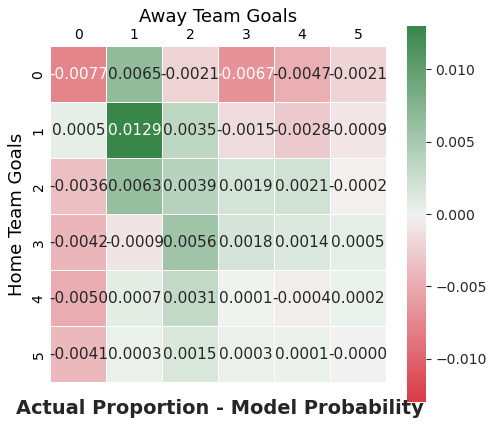

In [139]:
cmap = sns.diverging_palette(10, 133, as_cmap=True)

fig, ax = plt.subplots(figsize=(5,5))  
with sns.axes_style("white"):
    ax = sns.heatmap(np.mean(year_arrays, axis=0), annot=True, fmt='.4f', cmap=cmap, vmin=-0.013, vmax=.013, center=0.00,
                square=True, linewidths=.5, annot_kws={"size": 11}, cbar_kws={"shrink": .8})
    ax.tick_params(axis=u'both', which=u'both',length=0)
    ax.grid(which='major', axis='both', linestyle='')
    ax.set_xlabel('Away Team Goals', fontsize=13)
    ax.set_ylabel('Home Team Goals', fontsize=13)
    ax.xaxis.set_label_position('top')
    ax.xaxis.set_ticks_position('top')
    plt.figtext(0.45, 0.1, 'Actual Proportion - Model Probability', horizontalalignment='center',
                fontsize=14, multialignment='left', fontweight='bold')
plt.tight_layout()
plt.show()

In [140]:
def rho_correction(x, y, lambda_x, mu_y, rho):
    if x==0 and y==0:
        return 1- (lambda_x * mu_y * rho)
    elif x==0 and y==1:
        return 1 + (lambda_x * rho)
    elif x==1 and y==0:
        return 1 + (mu_y * rho)
    elif x==1 and y==1:
        return 1 - rho
    else:
        return 1.0

In [141]:
def dc_log_like(x, y, alpha_x, beta_x, alpha_y, beta_y, rho, gamma):
    lambda_x, mu_y = np.exp(alpha_x + beta_y + gamma), np.exp(alpha_y + beta_x) 
    return (np.log(rho_correction(x, y, lambda_x, mu_y, rho)) + 
            np.log(poisson.pmf(x, lambda_x)) + np.log(poisson.pmf(y, mu_y)))

In [122]:
def solve_parameters(dataset, debug = False, init_vals=None, options={'disp': True, 'maxiter':100},
                     constraints = [{'type':'eq', 'fun': lambda x: sum(x[:20])-20}] , **kwargs):
    teams = np.sort(dataset['HomeTeam'].unique())
    # check for no weirdness in dataset
    away_teams = np.sort(dataset['AwayTeam'].unique())
    if not np.array_equal(teams, away_teams):
        raise ValueError("Something's not right")
    n_teams = len(teams)
    if init_vals is None:
        # random initialisation of model parameters
        init_vals = np.concatenate((np.random.uniform(0,1,(n_teams)), # attack strength
                                      np.random.uniform(0,-1,(n_teams)), # defence strength
                                      np.array([0, 1.0]) # rho (score correction), gamma (home advantage)
                                     ))
    def dc_log_like(x, y, alpha_x, beta_x, alpha_y, beta_y, rho, gamma):
        lambda_x, mu_y = np.exp(alpha_x + beta_y + gamma), np.exp(alpha_y + beta_x) 
        return (np.log(rho_correction(x, y, lambda_x, mu_y, rho)) + 
                np.log(poisson.pmf(x, lambda_x)) + np.log(poisson.pmf(y, mu_y)))

    def estimate_paramters(params):
        score_coefs = dict(zip(teams, params[:n_teams]))
        defend_coefs = dict(zip(teams, params[n_teams:(2*n_teams)]))
        rho, gamma = params[-2:]
        log_like = [dc_log_like(row.FTHG, row.FTAG, score_coefs[row.HomeTeam], defend_coefs[row.HomeTeam],
                     score_coefs[row.AwayTeam], defend_coefs[row.AwayTeam], rho, gamma) for row in dataset.itertuples()]
        return -sum(log_like)
    opt_output = minimize(estimate_paramters, init_vals, options=options, constraints = constraints, **kwargs)
    if debug:
        # sort of hacky way to investigate the output of the optimisation process
        return opt_output
    else:
        return dict(zip(["attack_"+team for team in teams] + 
                        ["defence_"+team for team in teams] +
                        ['rho', 'home_adv'],
                        opt_output.x)) 
params = solve_parameters(epl_1718)

/var/folders/vl/qm5wc6yx7hgd_39xybtzb3mr0000gn/T/ipykernel_41677/1061560861.py:18: RuntimeWarning: divide by zero encountered in log
  np.log(poisson.pmf(x, lambda_x)) + np.log(poisson.pmf(y, mu_y)))
/var/folders/vl/qm5wc6yx7hgd_39xybtzb3mr0000gn/T/ipykernel_41677/1061560861.py:17: RuntimeWarning: invalid value encountered in log
  return (np.log(rho_correction(x, y, lambda_x, mu_y, rho)) +


Optimization terminated successfully    (Exit mode 0)
            Current function value: 5131.960171279674
            Iterations: 67
            Function evaluations: 3809
            Gradient evaluations: 67


In [142]:
params


{'attack_Arsenal': 1.2781385296656826,
 'attack_Aston Villa': 1.0722223090995824,
 'attack_Bournemouth': 0.8321113280200814,
 'attack_Brentford': 1.066462058392117,
 'attack_Brighton': 1.014663743365215,
 'attack_Burnley': 0.7022983720605528,
 'attack_Chelsea': 1.18340213539363,
 'attack_Crystal Palace': 0.7977649544671892,
 'attack_Everton': 0.8301086588520908,
 'attack_Fulham': 0.8589673569087555,
 'attack_Leeds': 1.0308497112656327,
 'attack_Leicester': 1.2145349947622104,
 'attack_Liverpool': 1.4701294572751593,
 'attack_Luton': 1.1490300463068863,
 'attack_Man City': 1.6156765906836061,
 'attack_Man United': 1.2045721820415982,
 'attack_Newcastle': 1.059467420176414,
 'attack_Norwich': 0.3006018697812953,
 "attack_Nott'm Forest": 0.8243511344589415,
 'attack_Sheffield United': 0.49464714702336116,
 'attack_Southampton': 0.8885059642671068,
 'attack_Tottenham': 1.3159443667243302,
 'attack_Watford': 0.6491462660464712,
 'attack_West Brom': 0.6690024011920891,
 'attack_West Ham': 1.

In [143]:
def calc_means(param_dict, homeTeam, awayTeam):
    return [np.exp(param_dict['attack_'+homeTeam] + param_dict['defence_'+awayTeam] + param_dict['home_adv']),
            np.exp(param_dict['defence_'+homeTeam] + param_dict['attack_'+awayTeam])]

def dixon_coles_simulate_match(params_dict, homeTeam, awayTeam, max_goals=10):
    team_avgs = calc_means(params_dict, homeTeam, awayTeam)
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in team_avgs]
    output_matrix = np.outer(np.array(team_pred[0]), np.array(team_pred[1]))
    correction_matrix = np.array([[rho_correction(home_goals, away_goals, team_avgs[0],
                                                   team_avgs[1], params['rho']) for away_goals in range(2)]
                                   for home_goals in range(2)])
    output_matrix[:2,:2] = output_matrix[:2,:2] * correction_matrix
    return output_matrix

In [151]:
ars_sou_dc = dixon_coles_simulate_match(params, 'Man City', 'Liverpool', max_goals=10)


In [152]:
ars_sou_dc

array([[4.52046784e-02, 5.50824026e-02, 3.39500693e-02, 1.39000785e-02,
        4.26830167e-03, 1.04853503e-03, 2.14649331e-04, 3.76642517e-05,
        5.78278705e-06, 7.89209917e-07, 9.69371792e-08],
       [8.40839589e-02, 1.03720414e-01, 6.35771968e-02, 2.60302275e-02,
        7.99311050e-03, 1.96355765e-03, 4.01966861e-04, 7.05326260e-05,
        1.08292383e-05, 1.47792789e-06, 1.81531121e-07],
       [7.89162425e-02, 9.69313458e-02, 5.95294802e-02, 2.43729827e-02,
        7.48421977e-03, 1.83854546e-03, 3.76375170e-04, 6.60420839e-05,
        1.01397822e-05, 1.38383388e-06, 1.69973729e-07],
       [4.92612984e-02, 6.05067322e-02, 3.71596442e-02, 1.52141655e-02,
        4.67181878e-03, 1.14766154e-03, 2.34941870e-04, 4.12249583e-05,
        6.32948072e-06, 8.63820320e-07, 1.06101435e-07],
       [2.30625101e-02, 2.83272502e-02, 1.73969160e-02, 7.12276892e-03,
        2.18719099e-03, 5.37297162e-04, 1.09992010e-04, 1.93001615e-05,
        2.96325347e-06, 4.04412094e-07, 4.96731818e-

In [153]:
# [Simple Poisson, Dixon-Coles]
print("Man City Win")
print('; '.join("{0}: {1:.5f}".format(model, prob) for model,prob in 
          zip(["Basic Poisson", "Dixon-Coles"], list(map(lambda x:np.sum(np.tril(x, -1)), [ars_sou, ars_sou_dc])))))
print("Southampton Win")
print('; '.join("{0}: {1:.5f}".format(model, prob) for model,prob in 
          zip(["Basic Poisson", "Dixon-Coles"], list(map(lambda x:np.sum(np.triu(x, 1)), [ars_sou, ars_sou_dc])))))
print("Draw")
print('; '.join("{0}: {1:.5f}".format(model, prob) for model,prob in 
          zip(["Basic Poisson", "Dixon-Coles"], list(map(lambda x:np.sum(np.diag(x)), [ars_sou, ars_sou_dc])))))

Man City Win
Basic Poisson: 0.52455; Dixon-Coles: 0.52439
Southampton Win
Basic Poisson: 0.24977; Dixon-Coles: 0.24953
Draw
Basic Poisson: 0.22567; Dixon-Coles: 0.22607


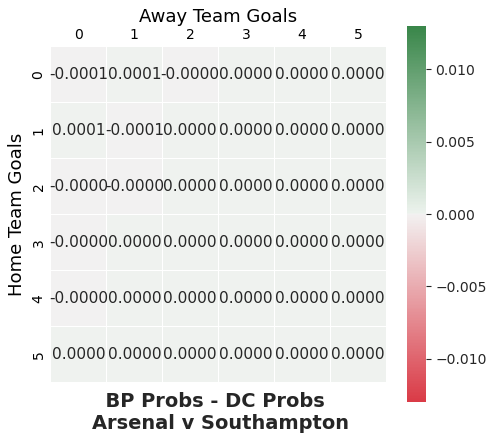

In [154]:
cmap = sns.diverging_palette(10, 133, as_cmap=True)

fig, ax = plt.subplots(figsize=(5,5))    
with sns.axes_style("white"):
    ax = sns.heatmap(simulate_match(poisson_model, 'Man City', 'Southampton', max_goals=5) - \
                     dixon_coles_simulate_match(params, 'Man City', 'Southampton', max_goals=5), 
                     annot=True, fmt='.4f', cmap=cmap, vmin=-0.013, vmax=.013, center=0.00,
                     square=True, linewidths=.5, annot_kws={"size": 11}, cbar_kws={"shrink": .8})
    ax.tick_params(axis=u'both', which=u'both',length=0)
    ax.grid(which='major', axis='both', linestyle='')
    ax.set_xlabel('Away Team Goals', fontsize=13)
    ax.set_ylabel('Home Team Goals', fontsize=13)
    ax.xaxis.set_label_position('top')
    ax.xaxis.set_ticks_position('top')
    plt.figtext(0.45, 0.07, '  BP Probs - DC Probs \nArsenal v Southampton', horizontalalignment='center',
                fontsize=14, multialignment='left', fontweight='bold')
plt.tight_layout()
plt.show()

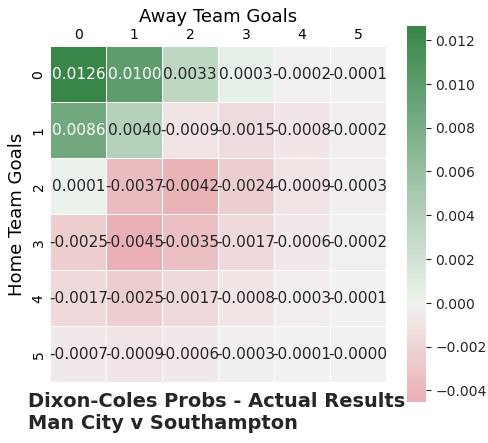

In [155]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Assuming dixon_coles_simulate_match and simulate_match functions are defined and working correctly
# Assuming 'params' variable is defined and contains the parameters for the Dixon-Coles model
# For the purpose of demonstration, let's create dummy functions and data

# Dummy function for basic Poisson simulation (replace with actual function)
def simulate_match(poisson_model, homeTeam, awayTeam, max_goals=5):
    # This should return a matrix of probabilities for different match outcomes (home goals x away goals)
    # For demonstration, let's create a dummy matrix with probabilities decreasing as the number of goals increase
    return np.array([[poisson.pmf(i, 1.5) * poisson.pmf(j, 1.2) for j in range(max_goals+1)] for i in range(max_goals+1)])

# Dummy function for Dixon-Coles simulation (replace with actual function)
def dixon_coles_simulate_match(params, homeTeam, awayTeam, max_goals=5):
    # This should return a matrix of probabilities with adjustments from the Dixon-Coles model
    # For demonstration, let's create a dummy matrix with probabilities decreasing as the number of goals increase
    return np.array([[poisson.pmf(i, 1.3) * poisson.pmf(j, 1.1) for j in range(max_goals+1)] for i in range(max_goals+1)])

# Dummy actual results matrix (replace with actual data)
actual_results = np.array([[poisson.pmf(i, 1.4) * poisson.pmf(j, 1.15) for j in range(6)] for i in range(6)])

# Dummy 'params' variable (replace with actual model parameters)
params = {'attack_Man City': 1.5, 'defence_Man City': -1.2, 'attack_Southampton': 1.2, 'defence_Southampton': -1.1}

# Create the color map
cmap = sns.diverging_palette(10, 133, as_cmap=True)

# Simulate the match outcomes using both models
basic_poisson_probs = simulate_match(None, 'Man City', 'Southampton', max_goals=5)
dixon_coles_probs = dixon_coles_simulate_match(params, 'Man City', 'Southampton', max_goals=5)

# Calculate the differences between the Dixon-Coles model probabilities and the actual results
difference = dixon_coles_probs - actual_results

# Create a heatmap of the differences
fig, ax = plt.subplots(figsize=(5,5))    
with sns.axes_style("white"):
    ax = sns.heatmap(difference, annot=True, fmt='.4f', cmap=cmap, center=0.00,
                     square=True, linewidths=.5, annot_kws={"size": 11}, cbar_kws={"shrink": .8})
    ax.tick_params(axis=u'both', which=u'both', length=0)
    ax.grid(which='major', axis='both', linestyle='')
    ax.set_xlabel('Away Team Goals', fontsize=13)
    ax.set_ylabel('Home Team Goals', fontsize=13)
    ax.xaxis.set_label_position('top')
    ax.xaxis.set_ticks_position('top')
    plt.figtext(0.45, 0.07, 'Dixon-Coles Probs - Actual Results \nMan City v Southampton', 
                horizontalalignment='center', fontsize=14, multialignment='left', fontweight='bold')
plt.tight_layout()
plt.show()


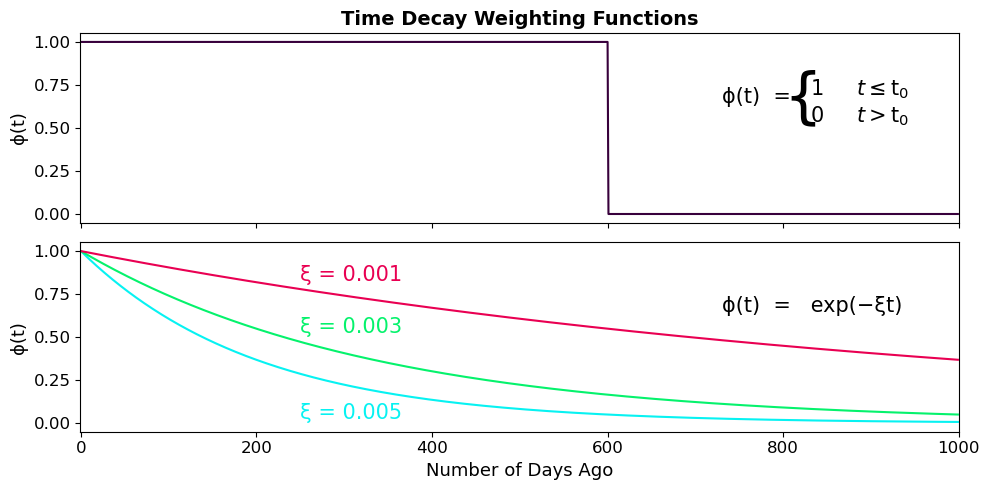

In [112]:
fig,(ax1,ax2) = plt.subplots(2, 1, figsize=(10,5))

ax1.plot(range(1000), [0 if y >600 else 1 for y in range(1000)], label='Component 1', color='#38003c', marker='')
ax2.plot(range(1000), np.exp([y*-0.005 for y in range(1000)]), label='Component 1', color='#07F2F2', marker='')
ax2.plot(range(1000), np.exp([y*-0.003 for y in range(1000)]), label='Component 1', color='#05F26C', marker='')
ax2.plot(range(1000), np.exp([y*-0.001 for y in range(1000)]), label='Component 1', color='#e90052', marker='')

ax1.set_ylim([-0.05,1.05])
ax2.set_ylim([-0.05,1.05])
ax1.set_xlim([-0.5,1000])
ax2.set_xlim([-0.5,1000])
ax1.set_xticklabels([])
ax2.xaxis.set_tick_params(labelsize=12)
ax1.yaxis.set_tick_params(labelsize=12)
ax2.yaxis.set_tick_params(labelsize=12)
ax1.set_title("Time Decay Weighting Functions",size=14,fontweight='bold')
ax2.set_xlabel("Number of Days Ago",size=13)
ax1.set_ylabel("ϕ(t)",size=13)
ax2.set_ylabel("ϕ(t)",size=13)
ax1.text(830, 0.5, '1     $t \leq \mathregular{t_0}$\n0     $t > \mathregular{t_0}$',
        verticalalignment='bottom', horizontalalignment='left',
        color='black', fontsize=15)
ax1.text(800, 0.5, '{',
        verticalalignment='bottom', horizontalalignment='left',
        color='black', fontsize=44)
ax1.text(730, 0.62, 'ϕ(t)  = ',
        verticalalignment='bottom', horizontalalignment='left',
        color='black', fontsize=15)
ax2.text(730, 0.62, 'ϕ(t)  =   exp(−ξt)',
        verticalalignment='bottom', horizontalalignment='left',
        color='black', fontsize=15)
ax2.text(250, 0.8, 'ξ = 0.001',
        verticalalignment='bottom', horizontalalignment='left',
        color='#e90052', fontsize=15)
ax2.text(250, 0.5, 'ξ = 0.003',
        verticalalignment='bottom', horizontalalignment='left',
        color='#05F26C', fontsize=15)
ax2.text(250, 0.0, 'ξ = 0.005',
        verticalalignment='bottom', horizontalalignment='left',
        color='#07F2F2', fontsize=15)
plt.tight_layout()
plt.show()

In [65]:
def dc_log_like_decay(x, y, alpha_x, beta_x, alpha_y, beta_y, rho, gamma, t, xi=0):
    lambda_x, mu_y = np.exp(alpha_x + beta_y + gamma), np.exp(alpha_y + beta_x) 
    return  np.exp(-xi*t) * (np.log(rho_correction(x, y, lambda_x, mu_y, rho)) + 
                              np.log(poisson.pmf(x, lambda_x)) + np.log(poisson.pmf(y, mu_y)))

In [68]:
epl_2023=pd.read_csv("2023.csv")

In [70]:
epl_2023

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,11/08/2023,20:00,Burnley,Man City,0,3,A,0,2,...,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,12/08/2023,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,...,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,12/08/2023,15:00,Bournemouth,West Ham,1,1,D,0,0,...,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,12/08/2023,15:00,Brighton,Luton,4,1,H,1,0,...,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,12/08/2023,15:00,Everton,Fulham,0,1,A,0,0,...,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,E0,04/02/2024,14:00,Bournemouth,Nott'm Forest,1,1,D,1,1,...,2.40,-0.75,1.83,2.10,1.84,2.10,1.85,2.12,1.81,2.07
224,E0,04/02/2024,14:00,Chelsea,Wolves,2,4,A,1,2,...,2.37,-1.00,1.88,2.05,1.88,2.04,1.95,2.06,1.87,2.00
225,E0,04/02/2024,14:00,Man United,West Ham,3,0,H,1,0,...,2.40,-1.00,1.90,2.03,1.93,2.00,2.02,2.06,1.89,1.99
226,E0,04/02/2024,16:30,Arsenal,Liverpool,3,1,H,1,1,...,2.20,-0.25,1.92,2.01,1.93,2.00,2.00,2.01,1.91,1.95


In [73]:
import pandas as pd

# 假设 epl_2023 是你的 DataFrame

# 确保 'Date' 列是日期时间格式
epl_2023['Date'] = pd.to_datetime(epl_2023['Date'])

# 计算时间差
epl_2023['time_diff'] = (epl_2023['Date'].max() - epl_2023['Date']).dt.days

# 继续你的处理
epl_2023 = epl_2023[['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'time_diff']]
epl_2023 = epl_2023.rename(columns={'FTHG': 'HomeGoals', 'FTAG': 'AwayGoals'})


/var/folders/vl/qm5wc6yx7hgd_39xybtzb3mr0000gn/T/ipykernel_41677/2451395187.py:6: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  epl_2023['Date'] = pd.to_datetime(epl_2023['Date'])


In [156]:
epl_2023

,HomeTeam,AwayTeam,HomeGoals,AwayGoals,FTR,time_diff
0,Burnley,Man City,0,3,A,178
1,Arsenal,Nott'm Forest,2,1,H,177
2,Bournemouth,West Ham,1,1,D,177
3,Brighton,Luton,4,1,H,177
4,Everton,Fulham,0,1,A,177
...,...,...,...,...,...,...
223,Bournemouth,Nott'm Forest,1,1,D,1
224,Chelsea,Wolves,2,4,A,1
225,Man United,West Ham,3,0,H,1
226,Arsenal,Liverpool,3,1,H,1


In [75]:
def solve_parameters_decay(dataset, xi=0.001, debug = False, init_vals=None, options={'disp': True, 'maxiter':100},
                     constraints = [{'type':'eq', 'fun': lambda x: sum(x[:20])-20}] , **kwargs):
    teams = np.sort(dataset['HomeTeam'].unique())
    # check for no weirdness in dataset
    away_teams = np.sort(dataset['AwayTeam'].unique())
    if not np.array_equal(teams, away_teams):
        raise ValueError("something not right")
    n_teams = len(teams)
    if init_vals is None:
        # random initialisation of model parameters
        init_vals = np.concatenate((np.random.uniform(0,1,(n_teams)), # attack strength
                                      np.random.uniform(0,-1,(n_teams)), # defence strength
                                      np.array([0,1.0]) # rho (score correction), gamma (home advantage)
                                     ))
        
    def dc_log_like_decay(x, y, alpha_x, beta_x, alpha_y, beta_y, rho, gamma, t, xi=xi):
        lambda_x, mu_y = np.exp(alpha_x + beta_y + gamma), np.exp(alpha_y + beta_x) 
        return  np.exp(-xi*t) * (np.log(rho_correction(x, y, lambda_x, mu_y, rho)) + 
                                  np.log(poisson.pmf(x, lambda_x)) + np.log(poisson.pmf(y, mu_y)))

    def estimate_paramters(params):
        score_coefs = dict(zip(teams, params[:n_teams]))
        defend_coefs = dict(zip(teams, params[n_teams:(2*n_teams)]))
        rho, gamma = params[-2:]
        log_like = [dc_log_like_decay(row.HomeGoals, row.AwayGoals, score_coefs[row.HomeTeam], defend_coefs[row.HomeTeam],
                                      score_coefs[row.AwayTeam], defend_coefs[row.AwayTeam], 
                                      rho, gamma, row.time_diff, xi=xi) for row in dataset.itertuples()]
        return -sum(log_like)
    opt_output = minimize(estimate_paramters, init_vals, options=options, constraints = constraints)
    if debug:
        # sort of hacky way to investigate the output of the optimisation process
        return opt_output
    else:
        return dict(zip(["attack_"+team for team in teams] + 
                        ["defence_"+team for team in teams] +
                        ['rho', 'home_adv'],
                        opt_output.x)) 

In [76]:
params_xi= solve_parameters_decay(epl_2023, xi=0.0018)


/var/folders/vl/qm5wc6yx7hgd_39xybtzb3mr0000gn/T/ipykernel_41677/1602507443.py:19: RuntimeWarning: divide by zero encountered in log
  np.log(poisson.pmf(x, lambda_x)) + np.log(poisson.pmf(y, mu_y)))
/var/folders/vl/qm5wc6yx7hgd_39xybtzb3mr0000gn/T/ipykernel_41677/1602507443.py:18: RuntimeWarning: invalid value encountered in log
  return  np.exp(-xi*t) * (np.log(rho_correction(x, y, lambda_x, mu_y, rho)) +


Optimization terminated successfully    (Exit mode 0)
            Current function value: 319.3422287656299
            Iterations: 34
            Function evaluations: 1500
            Gradient evaluations: 34


In [125]:
params_xi


{'attack_Arsenal': 1.2750225433936513,
 'attack_Aston Villa': 1.3146423563285428,
 'attack_Bournemouth': 0.8977834738788673,
 'attack_Brentford': 0.9046414097670626,
 'attack_Brighton': 1.1273762955282687,
 'attack_Burnley': 0.5778444580258714,
 'attack_Chelsea': 1.0692844051305854,
 'attack_Crystal Palace': 0.69824650839848,
 'attack_Everton': 0.6574563385490954,
 'attack_Fulham': 0.8038540907895438,
 'attack_Liverpool': 1.3876482574100626,
 'attack_Luton': 0.977912674378247,
 'attack_Man City': 1.4121043732302379,
 'attack_Man United': 0.8964074164446378,
 'attack_Newcastle': 1.36333174404495,
 "attack_Nott'm Forest": 0.8340763058256097,
 'attack_Sheffield United': 0.39384163056705584,
 'attack_Tottenham': 1.3189753222138652,
 'attack_West Ham': 0.9713096100313627,
 'attack_Wolves': 1.1182407860640031,
 'defence_Arsenal': -1.2015308270268776,
 'defence_Aston Villa': -0.8416904105626313,
 'defence_Bournemouth': -0.5847911917937748,
 'defence_Brentford': -0.5474643177496246,
 'defence_

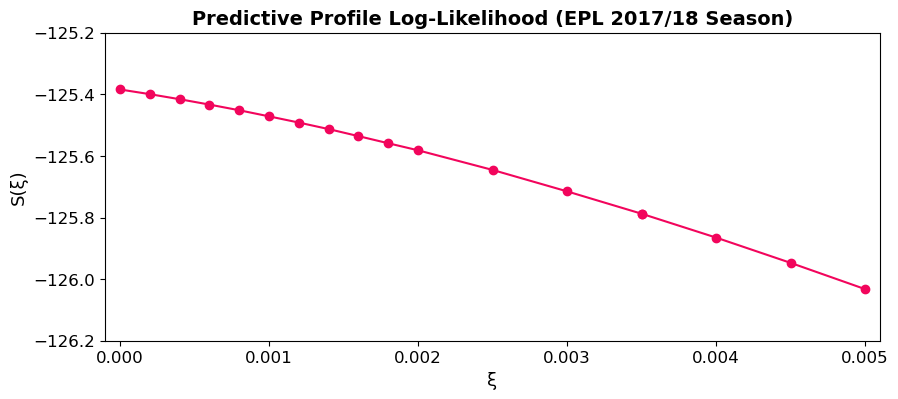

In [78]:
xi_vals = [0.0, 0.0002, 0.0004, 0.0006, 0.0008, 0.001, 0.0012, 0.0014, 0.0016, 0.0018, 
            0.002, 0.0025, 0.003, 0.0035,  0.0035, 0.004,  0.0045, 0.005]

# I pulled the scores from files on my computer that had been generated seperately
#xi_scores = []
#for xi in xi_vals:
#    with open ('find_xi__{}.txt'.format(str(xi)[2:]), 'rb') as fp:
#        xi_scores.append(sum(pickle.load(fp)))
        
xi_scores = [-125.38424297397718, -125.3994150871104, -125.41582329299528, -125.43330024318175, -125.45167361727589,
              -125.47148572476918, -125.49165987944551, -125.51283291929082, -125.53570389317336, -125.5588181265923,
              -125.58171066742123, -125.64545123148538, -125.71506317675832, -125.78763678848986, -125.78763678848986,
              -125.8651515986525, -125.94721517841089, -126.03247674382676]

fig, ax1 = plt.subplots(1, 1, figsize=(10,4))

ax1.plot(xi_vals, xi_scores, label='Component 1', color='#F2055C', marker='o')
ax1.set_ylim([-126.20, -125.20])
ax1.set_xlim([-0.0001,0.0051])
#ax1.set_xticklabels([])
ax1.set_ylabel('S(ξ)', fontsize=13)
ax1.set_xlabel('ξ', fontsize=13)
ax1.xaxis.set_tick_params(labelsize=12)
ax1.yaxis.set_tick_params(labelsize=12)
ax1.set_title("Predictive Profile Log-Likelihood (EPL 2017/18 Season)",size=14,fontweight='bold')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from multiprocessing import Pool
from scipy.stats import poisson
import concurrent.futures
from model_functions import get_total_score_xi
import pandas as pd

# 这里需要替换为你的 solve_parameters_decay 函数和 dixon_coles_simulate_match 函数


epl_2023 = pd.read_csv("2023.csv")  # 你需要确保路径和文件名正确
epl_2023['Date'] = pd.to_datetime(epl_2023['Date'], format='%d/%m/%Y')
epl_2023['time_diff'] = (max(epl_2023['Date']) - epl_2023['Date']).dt.days
epl_2023 = epl_2023[['HomeTeam','AwayTeam','FTHG','FTAG', 'FTR', 'time_diff']]
epl_2023 = epl_2023.rename(columns={'FTHG': 'HomeGoals', 'FTAG': 'AwayGoals'})

xi_vals = [0.0, 0.0002, 0.0004, 0.0006, 0.0008, 0.001, 0.0012, 0.0014, 0.0016, 0.0018, 
           0.002, 0.0025, 0.003, 0.0035, 0.0035, 0.004, 0.0045, 0.005]

if __name__ == "__main__":
    with concurrent.futures.ProcessPoolExecutor() as executor:
        # 使用executor.map来并行执行get_total_score_xi
        results = list(executor.map(get_total_score_xi, xi_vals))

        # 可选：处理results，例如打印或保存到文件等
        print(results)


In [84]:
results

NameError: name 'results' is not defined

In [81]:
epl_2023

,HomeTeam,AwayTeam,HomeGoals,AwayGoals,FTR,time_diff
0,Burnley,Man City,0,3,A,389
1,Arsenal,Nott'm Forest,2,1,H,359
2,Bournemouth,West Ham,1,1,D,359
3,Brighton,Luton,4,1,H,359
4,Everton,Fulham,0,1,A,359
...,...,...,...,...,...,...
223,Bournemouth,Nott'm Forest,1,1,D,243
224,Chelsea,Wolves,2,4,A,243
225,Man United,West Ham,3,0,H,243
226,Arsenal,Liverpool,3,1,H,243


In [5]:
# 显示所有列名
column_names = combined_df.columns

# 将列名转换为列表
column_names_list = list(column_names)

# 打印列名列表
print(column_names_list)


['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA']


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import poisson,skellam
from scipy.optimize import minimize

In [15]:
#后面是预测部分

import xgboost as xgb


class BoostModel:
    '''
    定义一个利用xgboost来做boosting tree的流程
    '''

    def __init__(self, max_depth=3, subsample=0.95, num_round=2000, early_stopping_rounds=50):
        '''
        初始化
        参数:
            max_depth：树的最大深度
            subsample： 采样率，也就是选取多少比例的样本进行训练
            num_round： 最大循环次数，也就是最大的树个数
            early_stopping_rounds：提前停止次数，假设为50，也就是说验证集的误差迭代到一定程度在50次内不能再继续降低，就停止迭代
        '''
        self.params = {
                        # 'objective':'multi:softmax',
                        # 'objective':'binary:logistic',
                        'objective':'binary:logistic',
                        # 'objective': 'reg:squarederror',
                    #    'num_class':2,
                       'booster':'gbtree',
                       'max_depth':max_depth,
                        'eta':0.01,
                        'silent': 0,
                        # 'subsample':subsample,
                        'colsample_bytree':0.7
                       ,'lambda':0.2,
                       'eval_metric':['logloss','error']
                       }
        # 下面的参数eta: 学习率；silent: 是否打印训练过程信息；alpha: L1 正则的惩罚系数；lambda: L2 正则的惩罚系数；
        # eval_metric: 评价指标；objective: 定义学习任务及相应的学习目标
        # self.params = {'max_depth': max_depth, 'eta': 0.02,  'alpha': 0.5, 'lambda': 0.5,
        #                'eval_metric': 'rmse', 'subsample': subsample, 'objective': 'reg:squarederror',
        #                'colsample_bytree': 0.8}
        # self.params = {'max_depth': max_depth, 'eta': 0.02, 'verbosity': 1, 'alpha': 0.5, 'lambda': 0.5,
        #                'eval_metric': 'rmse', 'subsample': subsample, 'objective': 'reg:squarederror','reg:linear',
        #                'colsample_bytree': 0.8,'tree_method':'gpu_hist'}
        
        self.num_round = num_round
        # self.early_stopping_rounds = early_stopping_rounds
        self.evals_result = {}
    def fit(self, train_data, train_label, val_data, val_label):
        '''
        训练模型
        参数:
            train_data, train_label：分别对应着训练特征数据，训练标签
            val_data, val_label： 分类对应着验证特征数据，验证标签
        返回:
            boost_model, 训练后的xgboost模型
        '''

        dtrain = xgb.DMatrix(train_data, label=train_label)
        deval = xgb.DMatrix(val_data, label=val_label)
        print('cp1')
        # boost_model = xgb.train(self.params, dtrain, num_boost_round=self.num_round,
        #                         evals=[(dtrain, 'train'), (deval, 'eval')],
        #                         early_stopping_rounds=self.early_stopping_rounds, verbose_eval=False)
        self.evals_result = {}
        boost_model = xgb.train(self.params, dtrain, num_boost_round=self.num_round,
                                evals=[(dtrain, 'train'), (deval, 'eval')],evals_result=self.evals_result)
        # print('get best eval auc : %s, in step %s' % (boost_model.best_score, boost_model.best_iteration))
        self.boost_model = boost_model
        return boost_model

    def predict(self, test_data):
        '''
        预测
        参数:
            test_data：待预测的特征数据
        返回:
            predict_score: 预测值
        '''
        dtest = xgb.DMatrix(test_data)
        predict_score = self.boost_model.predict(dtest, ntree_limit=self.boost_model.best_ntree_limit)

        return predict_score

In [16]:
import pandas as pd

combined_df['Date'] = pd.to_datetime(combined_df['Date'])



features = ['B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA','AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA']

# features = ['openret', 'step1ret', 'step1ret2',
#        'step2ret', 'step2ret2', 'step1range', 'step2range', 'auctionamount',
#        'volpct', 'uppct', 'downpct', 'step1num', 'step2num', 'stockopenret',
#        'stockstep1ret', 'stockstep1ret2', 'stockstep2ret', 'stockstep2ret2',
#        'stockstep1range', 'stockstep2range', 'stockauctionamount',
#        'stockvolpct', 'stockuppct', 'stockdownpct', 'stockstep1num',
#        'stockstep2num']


# output = ['gain']
output = ['FTR']

X_train, X_test, y_train, y_test = train_test_split(combined_df[features], combined_df[output], test_size=0.2, random_state=42)

# XGBoost模型配置
params = {
    'objective': 'multi:softprob',  # 修改为多分类的目标
    'booster': 'gbtree',
    'max_depth': 5,
    'eta': 0.02,
    'colsample_bytree': 0.7,
    'lambda': 0.2,
    'alpha': 0.2,
    'eval_metric': ['mlogloss', 'merror'],  # 修改为多分类的评估指标
    'num_class': 3  # 类的数量（平局，主胜，客胜）
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# 训练模型
evals = [(dtrain, 'train'), (dtest, 'eval')]
model = xgb.train(params, dtrain, num_boost_round=2000, early_stopping_rounds=30, evals=evals, verbose_eval=True)


[0]	train-mlogloss:1.09087	train-merror:0.36203	eval-mlogloss:1.09499	eval-merror:0.53235
[1]	train-mlogloss:1.08332	train-merror:0.34658	eval-mlogloss:1.09169	eval-merror:0.53235
[2]	train-mlogloss:1.07585	train-merror:0.33333	eval-mlogloss:1.08879	eval-merror:0.54118
[3]	train-mlogloss:1.06862	train-merror:0.32892	eval-mlogloss:1.08567	eval-merror:0.53235
[4]	train-mlogloss:1.06196	train-merror:0.33628	eval-mlogloss:1.08261	eval-merror:0.53824
[5]	train-mlogloss:1.05501	train-merror:0.33186	eval-mlogloss:1.07989	eval-merror:0.53529
[6]	train-mlogloss:1.04823	train-merror:0.32965	eval-mlogloss:1.07717	eval-merror:0.52059
[7]	train-mlogloss:1.04175	train-merror:0.32450	eval-mlogloss:1.07465	eval-merror:0.51765
[8]	train-mlogloss:1.03529	train-merror:0.31788	eval-mlogloss:1.07204	eval-merror:0.51176
[9]	train-mlogloss:1.02892	train-merror:0.32303	eval-mlogloss:1.06949	eval-merror:0.51471
[10]	train-mlogloss:1.02275	train-merror:0.32303	eval-mlogloss:1.06750	eval-merror:0.51471
[11]	trai

/var/folders/vl/qm5wc6yx7hgd_39xybtzb3mr0000gn/T/ipykernel_41677/1991563692.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df['Date'] = pd.to_datetime(combined_df['Date'])


[14]	train-mlogloss:0.99964	train-merror:0.31935	eval-mlogloss:1.05887	eval-merror:0.51471
[15]	train-mlogloss:0.99401	train-merror:0.31420	eval-mlogloss:1.05705	eval-merror:0.51765
[16]	train-mlogloss:0.98866	train-merror:0.31347	eval-mlogloss:1.05508	eval-merror:0.51176
[17]	train-mlogloss:0.98343	train-merror:0.31199	eval-mlogloss:1.05305	eval-merror:0.51471
[18]	train-mlogloss:0.97831	train-merror:0.31126	eval-mlogloss:1.05096	eval-merror:0.51176
[19]	train-mlogloss:0.97341	train-merror:0.31052	eval-mlogloss:1.04957	eval-merror:0.50588
[20]	train-mlogloss:0.96874	train-merror:0.31273	eval-mlogloss:1.04825	eval-merror:0.50294
[21]	train-mlogloss:0.96423	train-merror:0.31567	eval-mlogloss:1.04707	eval-merror:0.50882
[22]	train-mlogloss:0.95973	train-merror:0.31567	eval-mlogloss:1.04563	eval-merror:0.51176
[23]	train-mlogloss:0.95519	train-merror:0.31420	eval-mlogloss:1.04454	eval-merror:0.50882
[24]	train-mlogloss:0.95074	train-merror:0.31347	eval-mlogloss:1.04338	eval-merror:0.51176

In [10]:
combined_df = combined_df.dropna()


In [11]:
# 检查FTR列中的唯一值
unique_values = combined_df['FTR'].unique()
print(unique_values)
# 定义映射字典
mapping = {'D': 0, 'H': 1, 'A': 2}

# 应用映射
combined_df['FTR'] = combined_df['FTR'].map(mapping)

# 检查映射后的结果
print(combined_df['FTR'].unique())


['H' 'A' 'D']
[1 2 0]


/var/folders/vl/qm5wc6yx7hgd_39xybtzb3mr0000gn/T/ipykernel_41677/2606229213.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df['FTR'] = combined_df['FTR'].map(mapping)


In [12]:
combined_df

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,2019-09-08,20:00,Liverpool,Norwich,4,1,1,4,0,...,3.43,-2.25,1.91,1.99,1.94,1.98,1.99,2.07,1.90,1.99
1,E0,2019-10-08,12:30,West Ham,Man City,0,5,2,0,1,...,2.91,1.75,1.95,1.95,1.96,1.97,2.07,1.98,1.97,1.92
2,E0,2019-10-08,15:00,Bournemouth,Sheffield United,1,1,0,0,0,...,1.92,-0.50,1.95,1.95,1.98,1.95,2.00,1.96,1.96,1.92
3,E0,2019-10-08,15:00,Burnley,Southampton,3,0,1,0,0,...,1.71,0.00,1.87,2.03,1.89,2.03,1.90,2.07,1.86,2.02
4,E0,2019-10-08,15:00,Crystal Palace,Everton,0,0,0,0,0,...,1.71,0.25,1.82,2.08,1.97,1.96,2.03,2.08,1.96,1.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1713,E0,2023-12-30,17:30,Nott'm Forest,Man United,2,1,1,0,0,...,2.14,0.25,1.99,1.94,2.00,1.93,2.09,1.94,1.97,1.89
1714,E0,2023-12-31,14:00,Fulham,Arsenal,2,1,1,1,1,...,2.04,1.00,1.89,2.04,1.87,2.06,2.02,2.07,1.89,1.98
1715,E0,2023-12-31,14:00,Tottenham,Bournemouth,3,1,1,1,0,...,3.41,-0.75,1.98,1.95,2.00,1.93,2.00,2.00,1.93,1.93
1716,E0,2024-01-01,20:00,Liverpool,Newcastle,4,2,1,0,0,...,3.12,-1.50,2.01,1.92,1.98,1.93,2.14,1.94,2.01,1.87


In [17]:
# 获取测试集上的预测概率
pred_probs = model.predict(dtest)

# 选择概率最高的类别作为预测结果
y_pred = np.argmax(pred_probs, axis=1)
from sklearn.metrics import accuracy_score

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
from sklearn.metrics import classification_report

# 查看分类报告
print(classification_report(y_test, y_pred, target_names=['D', 'H', 'A']))


Accuracy: 0.48823529411764705
              precision    recall  f1-score   support

           D       0.14      0.01      0.02        96
           H       0.52      0.69      0.60       137
           A       0.46      0.65      0.54       107

    accuracy                           0.49       340
   macro avg       0.38      0.45      0.39       340
weighted avg       0.40      0.49      0.42       340



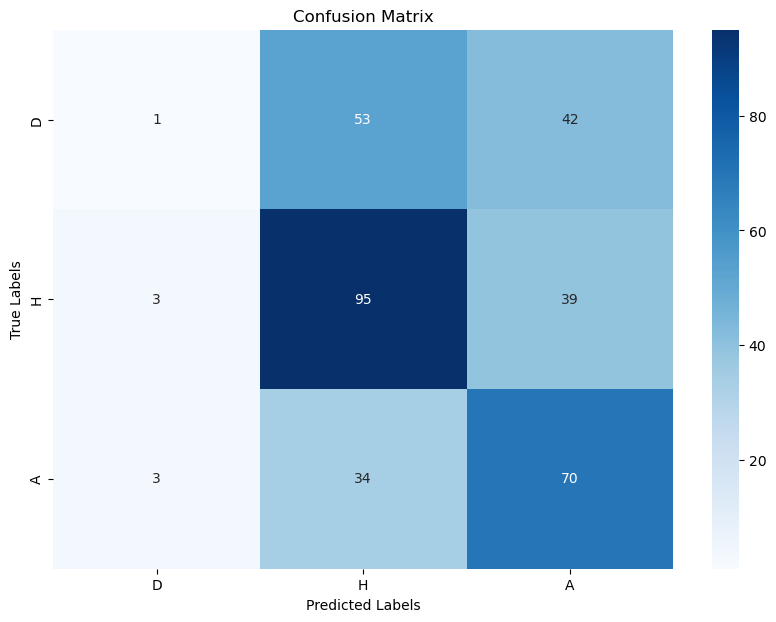

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred)

# 可视化混淆矩阵
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['D', 'H', 'A'], yticklabels=['D', 'H', 'A'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
